In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as ptl
import matplotlib.pyplot as plt

Loading The Data From Hugging Face

In [2]:
# Login using e.g. `huggingface-cli login` to access this dataset
df= pd.read_csv("hf://datasets/adegoke655/Insurance/insurance.csv")

In [3]:
# Saving locally as insurance_data.csv
df.to_csv("insurance_data.csv", index=False)

print("Dataset saved successfully as insurance_data.csv")

Dataset saved successfully as insurance_data.csv


Understanding My Data

In [4]:
insurance_data = pd.read_csv("insurance_data.csv")
print(insurance_data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
insurance_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [6]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Performing Exploratory Data Analysis

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

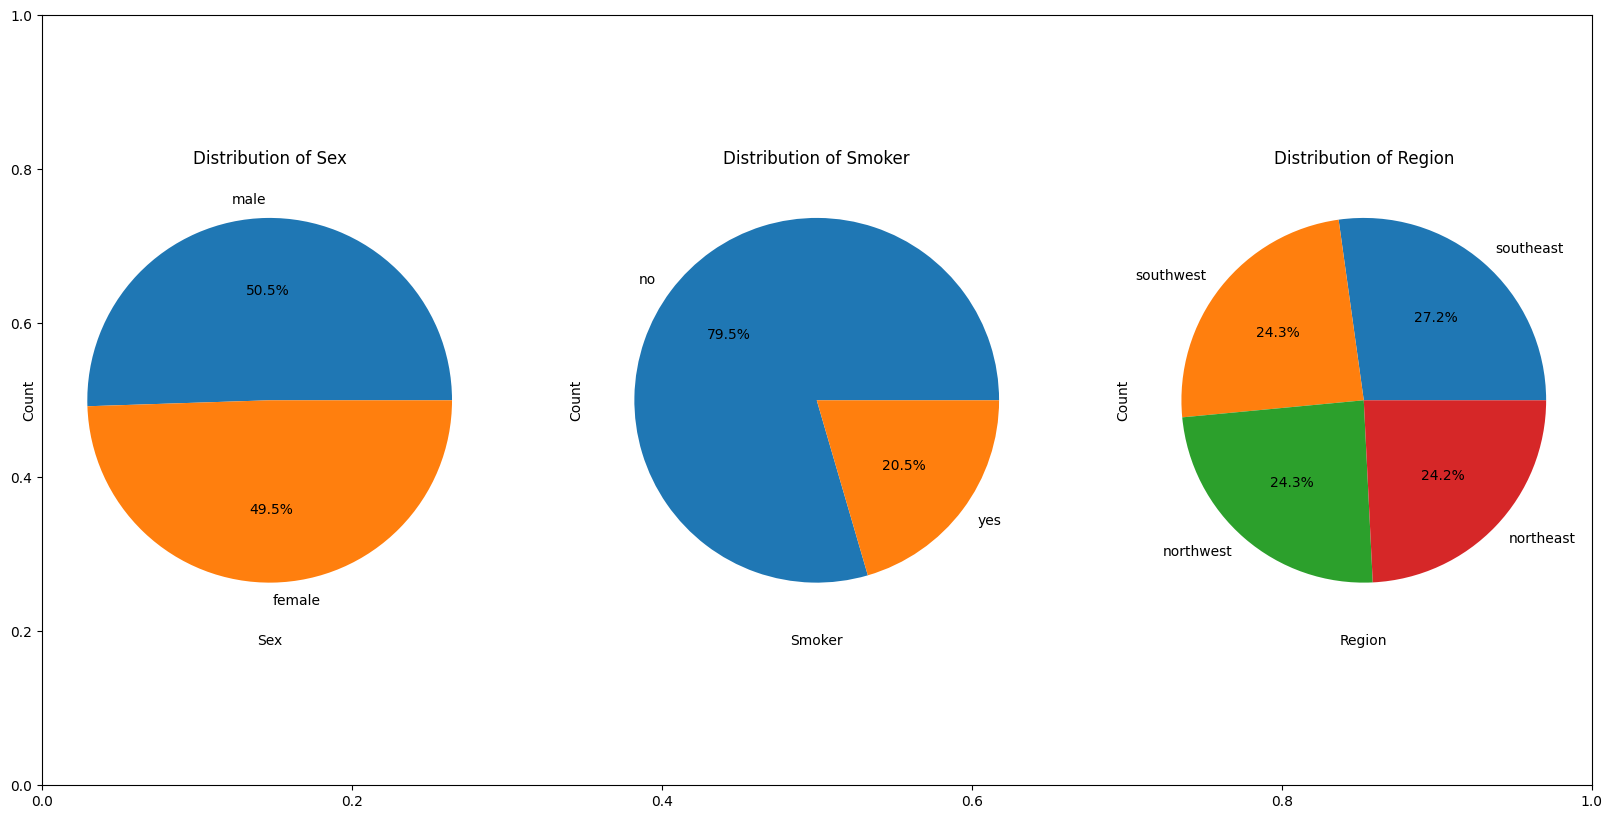

In [8]:
#Plotting the distribution of categorical features
features = ['sex', 'smoker', 'region']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    x = df[col].value_counts()
    plt.pie(x.values,
            labels=x.index,
            autopct='%1.1f%%')

plt.show()

According to the First Piechart,Charges are higher on the higher side for males as compared to females but the difference is very little                                                        
Also the cost charged from the smokers is around thrice that which is charged from non-smokers according to the second graph

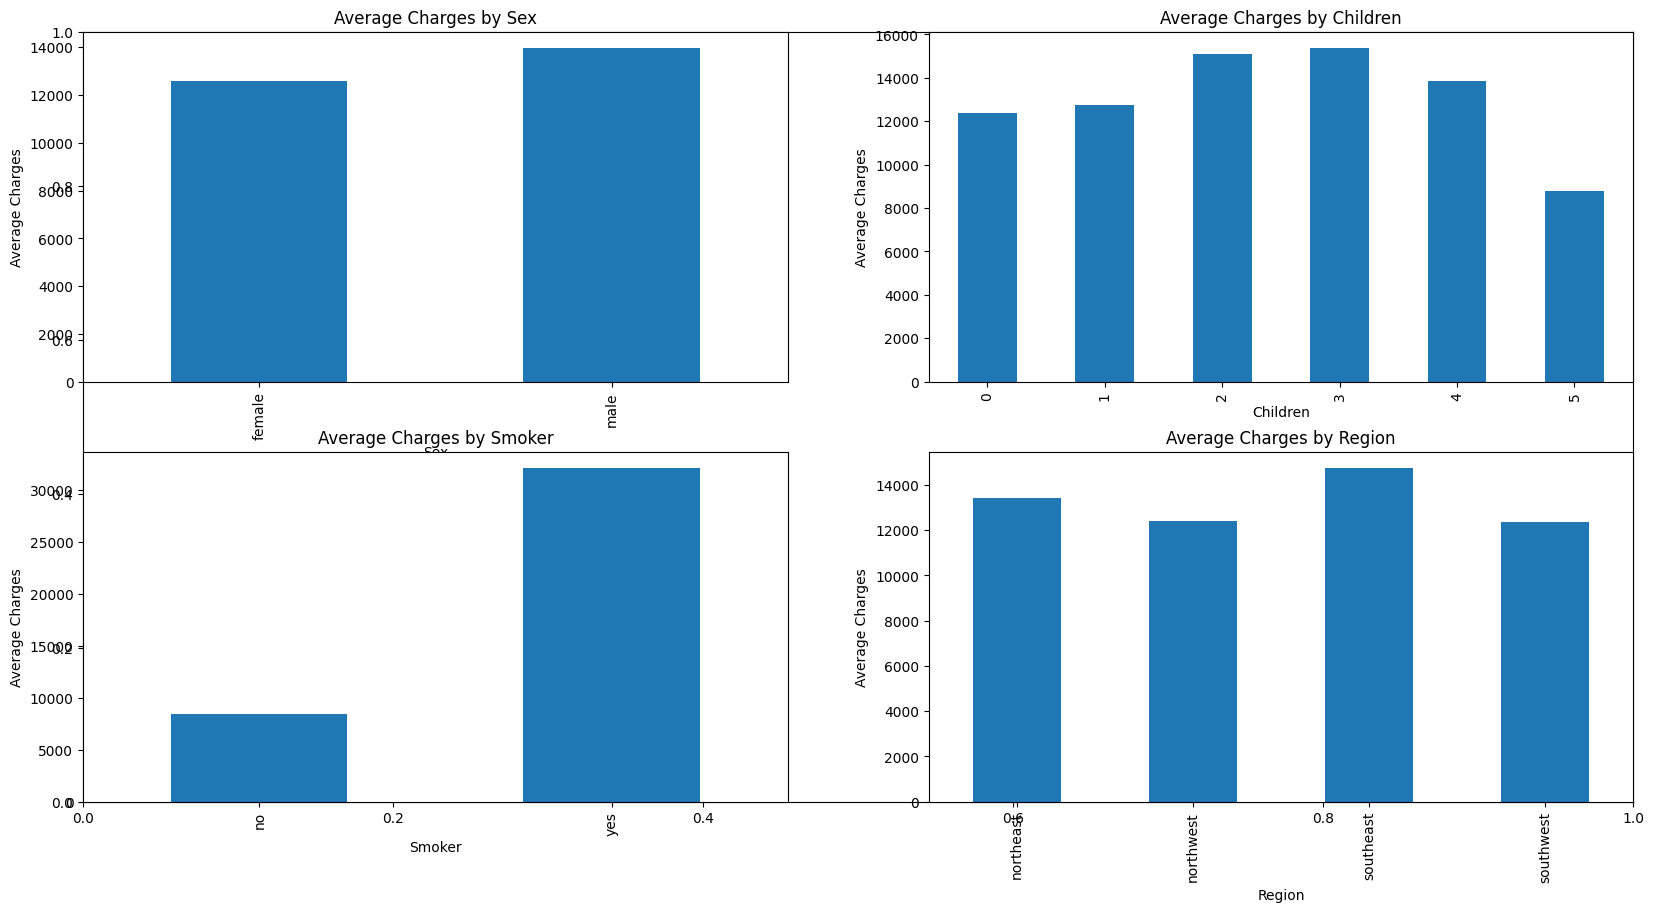

In [9]:
#Plotting the average charges
features = ['sex', 'children', 'smoker', 'region']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col)['charges'].mean().astype(float).plot.bar()
    plt.title(f'Average Charges by {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Average Charges')
plt.show()

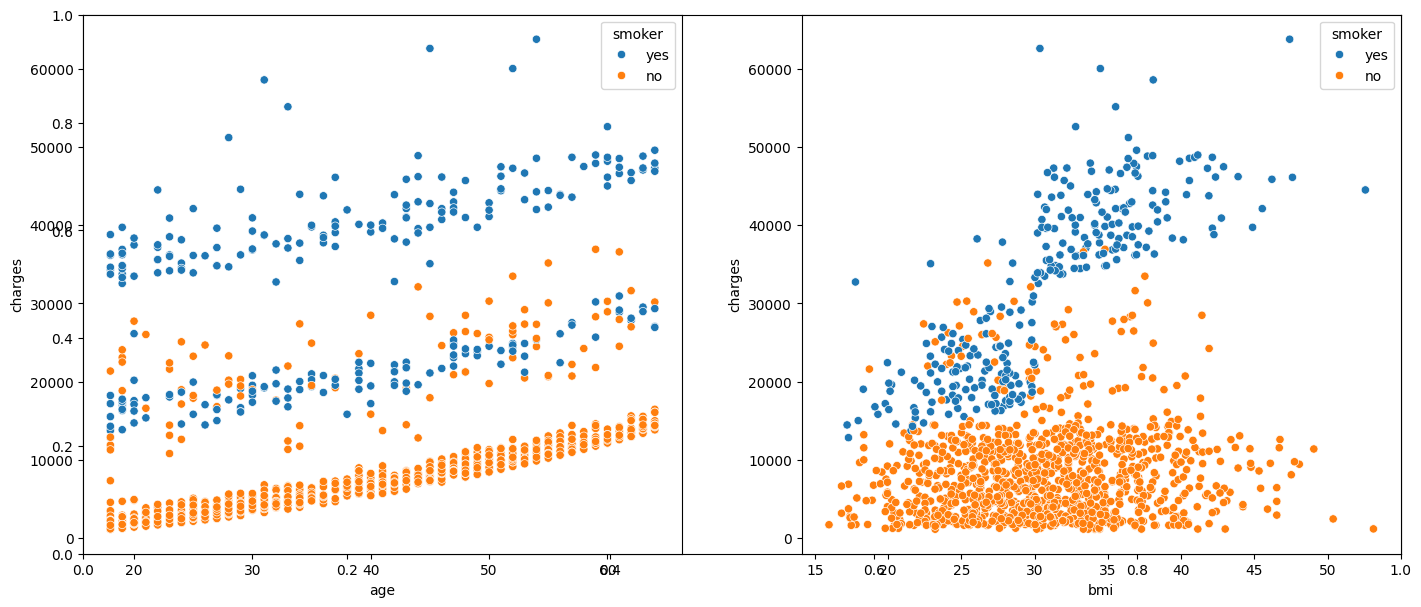

In [10]:
#Plotting the relationship between numerical features and charges
features = ['age', 'bmi']

plt.subplots(figsize=(17, 7))
for i, col in enumerate(features):
    plt.subplot(1, 2, i + 1)
    sns.scatterplot(data=df, x=col,
                   y='charges',
                   hue='smoker')
plt.show()

Performing Data Pre Processing

In [11]:
#check duplicates in the dataset
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 1


Text(0, 0.5, 'Count')

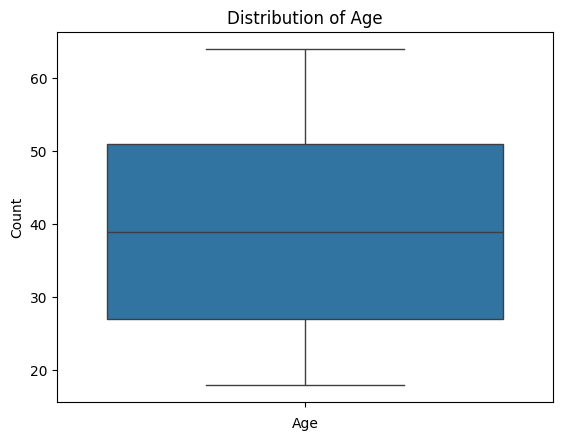

In [12]:
# Removing duplicates from the dataset
df.drop_duplicates(inplace=True)

#Plotting boxplot for age distribution
sns.boxplot(df['age'])
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

No oulliers detected in the age distribution column

Text(0, 0.5, 'Count')

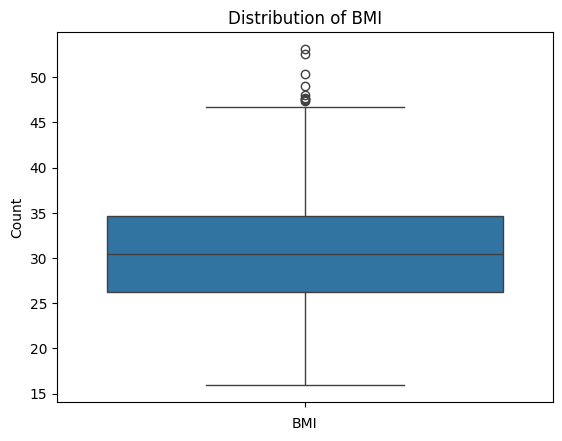

In [13]:
sns.boxplot(df['bmi'])
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')

Outliers detected in the BMI column

In [14]:
# Identifying outliers in the BMI column using IQR method
Q1=df['bmi'].quantile(0.25)
Q2=df['bmi'].quantile(0.5)
Q3=df['bmi'].quantile(0.75)
iqr=Q3-Q1
lowlim=Q1-1.5*iqr
upplim=Q3+1.5*iqr
print(lowlim)
print(upplim)

13.674999999999994
47.31500000000001


<Axes: title={'center': 'Distribution of BMI after capping outliers'}, xlabel='BMI', ylabel='Count'>

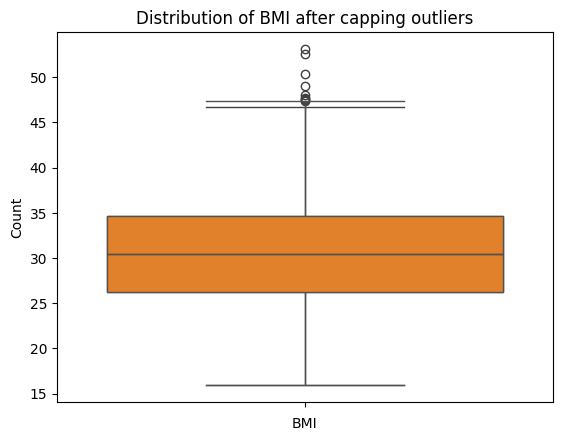

In [15]:
# Capping the outliers in the BMI column
sns.boxplot(df['bmi'])
plt.title('Distribution of BMI after capping outliers')
plt.xlabel('BMI')
plt.ylabel('Count')
from feature_engine.outliers import ArbitraryOutlierCapper
arb=ArbitraryOutlierCapper(min_capping_dict={'bmi':13.6749},max_capping_dict={'bmi':47.315})
df[['bmi']]=arb.fit_transform(df[['bmi']])
sns.boxplot(df['bmi'])

Successfully treated the outliers in the BMI column

Performing Data Wrangling

In [16]:
df['bmi'].skew()
df['age'].skew()

np.float64(0.054780773126998195)

In [17]:
# Encoding the categorical features for our model to perform well
df['sex']=df['sex'].map({'male':0,'female':1})
df['smoker']=df['smoker'].map({'yes':1,'no':0})
df['region']=df['region'].map({'northwest':0, 'northeast':1,'southeast':2,'southwest':3})

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520


In [19]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.019814,0.111998,0.041536,-0.025587,0.001771,0.298308
sex,0.019814,1.000000,-0.044831,-0.017848,-0.076596,-0.008998,-0.058044
bmi,0.111998,-0.044831,1.000000,0.013692,0.003151,0.156937,0.199063
children,0.041536,-0.017848,0.013692,1.000000,0.007331,-0.002842,0.067389
smoker,-0.025587,-0.076596,0.003151,0.007331,1.000000,0.012736,0.787234
region,0.001771,-0.008998,0.156937,-0.002842,0.012736,1.000000,0.010767
charges,0.298308,-0.058044,0.199063,0.067389,0.787234,0.010767,1.000000


DVELOPING THE COST PREDICTION MODEL

In [20]:
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

In [21]:
#Separating the features and target variable
X = df.drop(['charges'], axis=1)
Y = df[['charges']]

In [22]:
# Initializing storage for scores
l1 = [] # Train accuracy
l2 = [] # Test accuracy
l3 = [] # Cross-validation scores
cvs = 0

In [23]:
# Looping through different random states (40 to 49)
for i in range(40, 50):
    # Splitting the data into training and testing sets
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=i)
    
    # Initializing and fitting the model
    lrmodel = LinearRegression()
    lrmodel.fit(xtrain, ytrain)
    
    # Recording scores
    l1.append(lrmodel.score(xtrain, ytrain))
    l2.append(lrmodel.score(xtest, ytest))
    
    # Calculating and storing mean cross-validation score
    cvs = (cross_val_score(lrmodel, X, Y, cv=5)).mean()
    l3.append(cvs)

In [24]:
# Creating final results table
df1 = pd.DataFrame({'train acc': l1, 'test acc': l2, 'cvs': l3})
df1

,train acc,test acc,cvs
0,0.741659,0.778409,0.74707
1,0.756401,0.706267,0.74707
2,0.729542,0.806239,0.74707
3,0.754260,0.732791,0.74707
4,0.742966,0.779591,0.74707
5,0.753281,0.731769,0.74707
6,0.741261,0.776456,0.74707
7,0.731940,0.796173,0.74707
8,0.751915,0.741742,0.74707
9,0.756348,0.722565,0.74707


In [25]:
# For a single random state (42)
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=42)
lrmodel=LinearRegression()
lrmodel.fit(xtrain,ytrain)
print(lrmodel.score(xtrain,ytrain))
print(lrmodel.score(xtest,ytest))
print(cross_val_score(lrmodel,X,Y,cv=5,).mean())

0.7295415541376447
0.8062391115570589
0.7470697972809902


Applying Support Vector Regreesor

In [26]:
# For SVR model
svrmodel=SVR()
svrmodel.fit(xtrain,ytrain)
ypredtrain1=svrmodel.predict(xtrain)
ypredtest1=svrmodel.predict(xtest)
print(r2_score(ytrain,ypredtrain1))
print(r2_score(ytest,ypredtest1))
print(cross_val_score(svrmodel,X,Y,cv=5,).mean())

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-0.10151474302536445
-0.1344454720199666


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

-0.10374591327267262


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Applying Random Forest Regressor

In [27]:
# Initial model training for Random Forest Regressor
rfmodel = RandomForestRegressor(random_state=42)
rfmodel.fit(xtrain, ytrain)

# Initial performance check
ypredtrain2 = rfmodel.predict(xtrain)
ypredtest2 = rfmodel.predict(xtest)
print(f"Baseline Train R2: {r2_score(ytrain, ypredtrain2)}")
print(f"Baseline Test R2: {r2_score(ytest, ypredtest2)}")
print(f"Baseline CV Score: {cross_val_score(rfmodel, X, Y, cv=5).mean()}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline Train R2: 0.9738163260247533
Baseline Test R2: 0.8819423353068565


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

Baseline CV Score: 0.8363637309718952


In [28]:
# Setting up the grid search parameters
estimator = RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [10, 40, 50, 98, 100, 120, 150]}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=5)


In [29]:
# Running grid search
grid.fit(xtrain, ytrain)

# Displaying the best parameters found
print(f"Best Parameters: {grid.best_params_}")


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

Best Parameters: {'n_estimators': 120}


In [30]:
# Training the final model with optimized n_estimators
rfmodel = RandomForestRegressor(random_state=42, n_estimators=120)
rfmodel.fit(xtrain, ytrain)

# Final performance check
ypredtrain2 = rfmodel.predict(xtrain)
ypredtest2 = rfmodel.predict(xtest)
print(f"Final Train R2: {r2_score(ytrain, ypredtrain2)}")
print(f"Final Test R2: {r2_score(ytest, ypredtest2)}")
print(f"Final CV Score: {cross_val_score(rfmodel, X, Y, cv=5).mean()}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Final Train R2: 0.9746383984429655
Final Test R2: 0.8822009842175969


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

Final CV Score: 0.8367438097052858


Applying Gradient Boosting Regressor

In [31]:
# Initial Gradient Boosting model
gbmodel = GradientBoostingRegressor()
gbmodel.fit(xtrain, ytrain)

# Initial performance metrics
ypredtrain3 = gbmodel.predict(xtrain)
ypredtest3 = gbmodel.predict(xtest)
print(f"Baseline Train R2: {r2_score(ytrain, ypredtrain3)}")
print(f"Baseline Test R2: {r2_score(ytest, ypredtest3)}")
print(f"Baseline CV Score: {cross_val_score(gbmodel, X, Y, cv=5).mean()}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Baseline Train R2: 0.893134582116604
Baseline Test R2: 0.9042609532447069


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y w

Baseline CV Score: 0.8553608181805267


In [32]:
# Defining the model and parameter grid
estimator = GradientBoostingRegressor()
param_grid = {
    'n_estimators': [10, 15, 19, 20, 21, 50],
    'learning_rate': [0.1, 0.19, 0.2, 0.21, 0.8, 1]
}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=5)

In [33]:
# Fitting the grid search
grid.fit(xtrain, ytrain)

# Output the best settings found
print(f"Best Parameters: {grid.best_params_}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y w

Best Parameters: {'learning_rate': 0.2, 'n_estimators': 20}


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [34]:
# Training the final model with optimized parameters
gbmodel = GradientBoostingRegressor(n_estimators=19, learning_rate=0.2)
gbmodel.fit(xtrain, ytrain)

# Final performance evaluation
ypredtrain3 = gbmodel.predict(xtrain)
ypredtest3 = gbmodel.predict(xtest)
print(f"Final Train R2: {r2_score(ytrain, ypredtrain3)}")
print(f"Final Test R2: {r2_score(ytest, ypredtest3)}")
print(f"Final CV Score: {cross_val_score(gbmodel, X, Y, cv=5).mean()}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Final Train R2: 0.8682397447116927
Final Test R2: 0.9017109716082662


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y w

Final CV Score: 0.8606041910125791


XGBoost Gradient Boosting

In [35]:
# Initial XGmodel training
xgmodel = XGBRegressor()
xgmodel.fit(xtrain, ytrain)

# Initial performance check
ypredtrain4 = xgmodel.predict(xtrain)
ypredtest4 = xgmodel.predict(xtest)
print(f"Baseline Train R2: {r2_score(ytrain, ypredtrain4)}")
print(f"Baseline Test R2: {r2_score(ytest, ypredtest4)}")
print(f"Baseline CV Score: {cross_val_score(xgmodel, X, Y, cv=5).mean()}")

Baseline Train R2: 0.9954123497009277
Baseline Test R2: 0.8548938035964966
Baseline CV Score: 0.8081253051757813


In [36]:
# Settingup  the estimator and parameter grid
estimator = XGBRegressor()
param_grid = {
    'n_estimators': [10, 15, 20, 40, 50],
    'max_depth': [3, 4, 5],
    'gamma': [0, 0.15, 0.3, 0.5, 1]
}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=5)


In [37]:
# Running the grid search
grid.fit(xtrain, ytrain)

# Showing the best performing parameters
print(f"Best Parameters: {grid.best_params_}")


Best Parameters: {'gamma': 0, 'max_depth': 3, 'n_estimators': 10}


In [38]:
# Training the final model with optimized settings
xgmodel = XGBRegressor(n_estimators=15, max_depth=3, gamma=0)
xgmodel.fit(xtrain, ytrain)

# Final performance evaluation
ypredtrain4 = xgmodel.predict(xtrain)
ypredtest4 = xgmodel.predict(xtest)
print(f"Final Train R2: {r2_score(ytrain, ypredtrain4)}")
print(f"Final Test R2: {r2_score(ytest, ypredtest4)}")
print(f"Final CV Score: {cross_val_score(xgmodel, X, Y, cv=5).mean()}")

Final Train R2: 0.869317352771759
Final Test R2: 0.9022461175918579
Final CV Score: 0.8607115387916565


Comaprision of All Models Above

| Model | Train Accuracy | Test Accuracy | CV Score |
|------|---------------|--------------|----------|
| LinearRegression | 0.729 | 0.806 | 0.747 |
| SupportVectorMachine | -0.105 | -0.134 | 0.103 |
| RandomForest | 0.974 | 0.882 | 0.836 |
| GradientBoost | 0.868 | 0.901 | 0.860 |
| XGBoost | 0.870 | 0.904 | 0.860 |

In [39]:
# Feature importance from the best estimator
feats=pd.DataFrame(data=grid.best_estimator_.feature_importances_,index=X.columns,columns=['Importance'])
feats

,Importance
age,0.038633
sex,0.000000
bmi,0.133449
children,0.011073
smoker,0.809626
region,0.007219


In [40]:
# Filtering important features with importance greater than 0.01
important_features=feats[feats['Importance']>0.01]
important_features

,Importance
age,0.038633
bmi,0.133449
children,0.011073
smoker,0.809626


Training the champion Model

In [41]:
# Dropping non-essential categorical columns
df.drop(df[['sex', 'region']], axis=1, inplace=True)

# Defining final feature sets
Xf = df.drop(df[['charges']], axis=1)
X = df.drop(df[['charges']], axis=1)

In [42]:
# Splitting the data
xtrain, xtest, ytrain, ytest = train_test_split(Xf, Y, test_size=0.2, random_state=42)

In [43]:
# Initializing and fitting the final champion model
finalmodel = XGBRegressor(n_estimators=15, max_depth=3, gamma=0)
finalmodel.fit(xtrain, ytrain)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [44]:
# Generating predictions and printing final metrics
ypredtrain4 = finalmodel.predict(xtrain)
ypredtest4 = finalmodel.predict(xtest)

print(f"Final Train R2 Score: {r2_score(ytrain, ypredtrain4)}")
print(f"Final Test R2 Score: {r2_score(ytest, ypredtest4)}")
print(f"Final CV Mean Score: {cross_val_score(finalmodel, X, Y, cv=5).mean()}")

Final Train R2 Score: 0.8691051602363586
Final Test R2 Score: 0.9007425308227539
Final CV Mean Score: 0.8606266975402832


In [45]:
#saving the model
from pickle import dump
dump(finalmodel,open('insurancemodelf.pkl','wb'))

In [46]:
new_data=pd.DataFrame({'age':60,'sex':'female','bmi':23.9,'children':4,'smoker':'yes','region':'southwest'},index=[0])
new_data['smoker']=new_data['smoker'].map({'yes':1,'no':0})
new_data=new_data.drop(new_data[['sex','region']],axis=1)
finalmodel.predict(new_data)

array([29505.65], dtype=float32)

Deep Learning Regression Model

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Building a deep learning regression model
dnn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(xtrain.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Compiling the model
dnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

c:\Users\byamu\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
# Training the deep learning model
history = dnn_model.fit(xtrain, ytrain, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 306580384.0000 - mae: 13108.5342 - val_loss: 302618368.0000 - val_mae: 12553.5430
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 304925120.0000 - mae: 13050.1787 - val_loss: 300618112.0000 - val_mae: 12479.5947
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 302290560.0000 - mae: 12952.2852 - val_loss: 297225440.0000 - val_mae: 12353.2617
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 297777888.0000 - mae: 12788.8574 - val_loss: 291719008.0000 - val_mae: 12145.3750
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 290554848.0000 - mae: 12524.4492 - val_loss: 283141856.0000 - val_mae: 11814.4150
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 279959264.0000 - mae: 12115.9414 - val_loss: 270916896.0000 - val_mae: 11326.4160
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 265368608.0000 - mae: 11543.1025 - val_loss: 254961760.0000 - val_mae: 10658.7061
Epoch 8/1

In [49]:
# Evaluating the model on test data
dnn_test_loss, dnn_test_mae = dnn_model.evaluate(xtest, ytest, verbose=1)
print(f"Deep Learning Model Test MAE: {dnn_test_mae:.2f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 152060608.0000 - mae: 9456.9678  
Deep Learning Model Test MAE: 9456.97


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


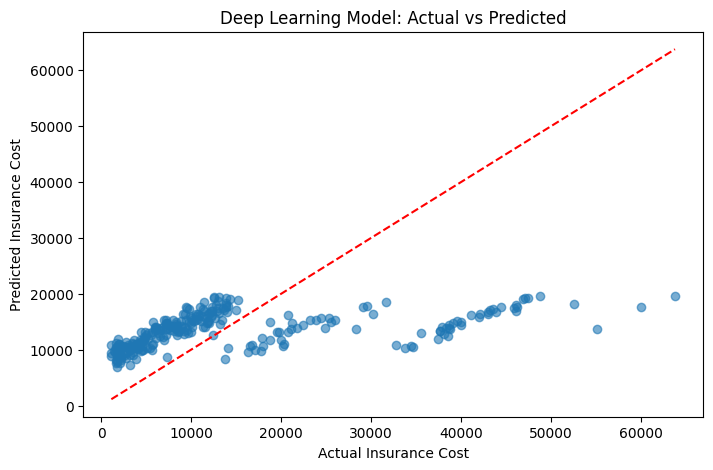

In [50]:
# Predicting insurance costs using the deep learning model
dnn_predictions = dnn_model.predict(xtest)

# Comparing predictions with actual values
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(ytest, dnn_predictions, alpha=0.6)
plt.xlabel('Actual Insurance Cost')
plt.ylabel('Predicted Insurance Cost')
plt.title('Deep Learning Model: Actual vs Predicted')
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--')
plt.show()

Model Interpretation with SHAP

In [51]:
import shap

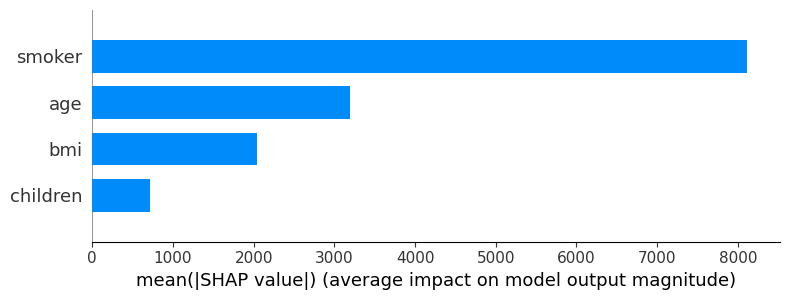

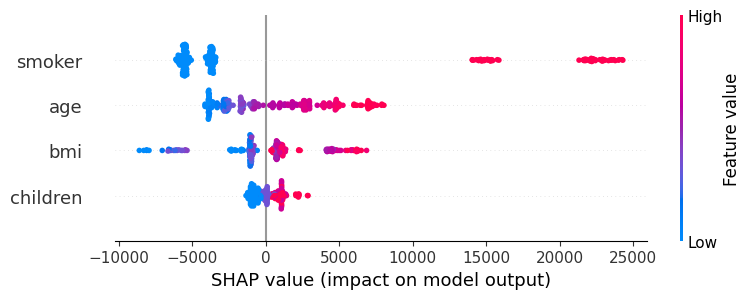

In [52]:
# SHAP for XGBoost model
explainer_xgb = shap.Explainer(finalmodel, xtrain)
shap_values_xgb = explainer_xgb(xtest)

# Summary plot for XGBoost
shap.summary_plot(shap_values_xgb, xtest, plot_type="bar")
shap.summary_plot(shap_values_xgb, xtest)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Using 1069 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/268 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
468/468 ━━━━━━

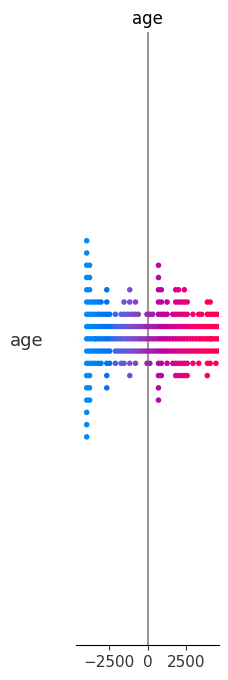

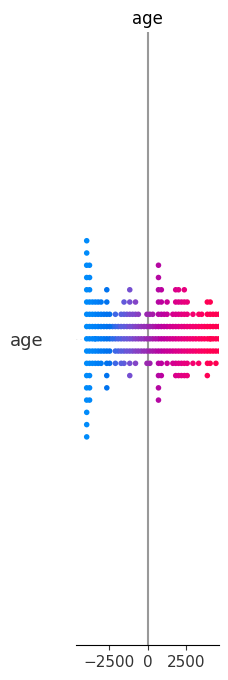

In [53]:
# SHAP for Deep Learning model
explainer_dnn = shap.KernelExplainer(dnn_model.predict, xtrain)
shap_values_dnn = explainer_dnn.shap_values(xtest, nsamples=100)

# Summary plot for Deep Learning model
shap.summary_plot(shap_values_dnn, xtest, plot_type="bar")
shap.summary_plot(shap_values_dnn, xtest)

In [54]:
# Calculate R2 score for the deep learning model
from sklearn.metrics import r2_score

dnn_r2 = r2_score(ytest, dnn_predictions)
print(f"Deep Learning Model R2 Score: {dnn_r2:.4f}")

Deep Learning Model R2 Score: 0.1725


In [ ]:
# Feature scaling for deep learning
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
extest_scaled = scaler.transform(xtest)

# Re-training the deep learning model with scaled features
dnn_model_scaled = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(xtrain_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
dnn_model_scaled.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_scaled = dnn_model_scaled.fit(xtrain_scaled, ytrain, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

dnn_predictions_scaled = dnn_model_scaled.predict(extest_scaled)
dnn_r2_scaled = r2_score(ytest, dnn_predictions_scaled)
print(f"Deep Learning Model (Scaled) R2 Score: {dnn_r2_scaled:.4f}")

Epoch 1/100


c:\Users\byamu\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 307338816.0000 - mae: 13135.3027 - val_loss: 304032736.0000 - val_mae: 12605.4307
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 307282368.0000 - mae: 13133.3135 - val_loss: 303954432.0000 - val_mae: 12602.5723
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 307167104.0000 - mae: 13129.3389 - val_loss: 303798528.0000 - val_mae: 12597.0811
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 306947360.0000 - mae: 13122.0020 - val_loss: 303516544.0000 - val_mae: 12587.5293
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 306568832.0000 - mae: 13109.8408 - val_loss: 303044704.0000 - val_mae: 12572.2969
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 305960000.0000 - mae: 13090.9668 - val_loss: 302310720.0000 - val_mae: 12549.4922
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 305028768.0000 - mae: 13063.2666 - val_loss: 301218432.0000 - val_mae: 12516.7549
Epoch 8/100
27/27 